In [24]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, classification_report
#from sklearn.tree import DecisionTreeClassifier
#from sklearn.naive_bayes import GaussianNB, MultinomialNB
#from sklearn.base import BaseEstimator, TransformerMixin
#from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
#from sklearn.metrics import classification_report, cohen_kappa_score, accuracy_score
from sklearn.linear_model import LogisticRegression, LinearRegression, Lasso, Ridge
#from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import MinMaxScaler, StandardScaler, FunctionTransformer,\
KBinsDiscretizer, OneHotEncoder, QuantileTransformer

In [12]:
from sklearn.datasets import load_digits
dataset = load_digits()

In [13]:
dataset.keys()

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

In [15]:
df = pd.DataFrame(dataset.data, columns= dataset.feature_names)
df['target'] = dataset.target 
df

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7,target
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1792,0.0,0.0,4.0,10.0,13.0,6.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,2.0,14.0,15.0,9.0,0.0,0.0,9
1793,0.0,0.0,6.0,16.0,13.0,11.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,16.0,14.0,6.0,0.0,0.0,0
1794,0.0,0.0,1.0,11.0,15.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,9.0,13.0,6.0,0.0,0.0,8
1795,0.0,0.0,2.0,10.0,7.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,5.0,12.0,16.0,12.0,0.0,0.0,9


<Figure size 640x480 with 0 Axes>

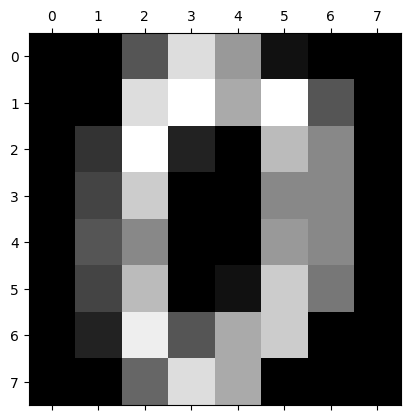

In [9]:
plt.gray()
plt.matshow(dataset.data[0].reshape(8,8))

<Figure size 640x480 with 0 Axes>

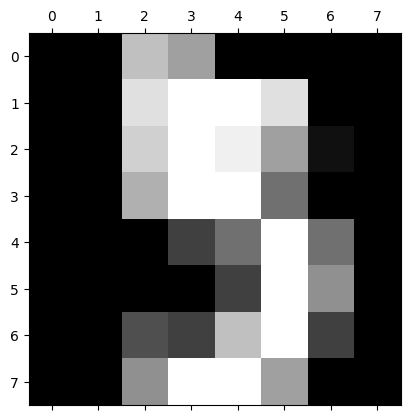

In [10]:
plt.gray()
plt.matshow(dataset.data[5].reshape(8,8))

In [16]:
df.describe()

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7,target
count,1797.0,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,...,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000
mean,0.0,0.303840,5.204786,11.835838,11.848080,5.781859,1.362270,0.129661,0.005565,1.993879,...,0.206455,0.000556,0.279354,5.557596,12.089037,11.809126,6.764051,2.067891,0.364496,4.490818
std,0.0,0.907192,4.754826,4.248842,4.287388,5.666418,3.325775,1.037383,0.094222,3.196160,...,0.984401,0.023590,0.934302,5.103019,4.374694,4.933947,5.900623,4.090548,1.860122,2.865304
min,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.0,0.000000,1.000000,10.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,11.000000,10.000000,0.000000,0.000000,0.000000,2.000000
50%,0.0,0.000000,4.000000,13.000000,13.000000,4.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,4.000000,13.000000,14.000000,6.000000,0.000000,0.000000,4.000000
75%,0.0,0.000000,9.000000,15.000000,15.000000,11.000000,0.000000,0.000000,0.000000,3.000000,...,0.000000,0.000000,0.000000,10.000000,16.000000,16.000000,12.000000,2.000000,0.000000,7.000000
max,0.0,8.000000,16.000000,16.000000,16.000000,16.000000,16.000000,15.000000,2.000000,16.000000,...,13.000000,1.000000,9.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,9.000000


In [17]:
X = df 
y = df['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[ 0.        , -0.33501649, -0.04308102, ..., -0.5056698 ,
        -0.19600752, -1.56774584],
       [ 0.        , -0.33501649, -1.09493684, ..., -0.5056698 ,
        -0.19600752, -1.21864556],
       [ 0.        , -0.33501649, -1.09493684, ...,  1.6951369 ,
        -0.19600752, -0.86954528],
       ...,
       [ 0.        , -0.33501649, -0.88456568, ..., -0.5056698 ,
        -0.19600752,  1.22505642],
       [ 0.        , -0.33501649, -0.67419451, ..., -0.5056698 ,
        -0.19600752,  1.5741567 ],
       [ 0.        , -0.33501649,  1.00877481, ..., -0.26113572,
        -0.19600752,  1.22505642]])

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=12)

In [21]:
log_reg_model = LogisticRegression()
log_reg_model.fit(X_train, y_train)
log_reg_model.score(X_test, y_test)

0.9805555555555555

### PCA

In [22]:
X

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7,target
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1792,0.0,0.0,4.0,10.0,13.0,6.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,2.0,14.0,15.0,9.0,0.0,0.0,9
1793,0.0,0.0,6.0,16.0,13.0,11.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,16.0,14.0,6.0,0.0,0.0,0
1794,0.0,0.0,1.0,11.0,15.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,9.0,13.0,6.0,0.0,0.0,8
1795,0.0,0.0,2.0,10.0,7.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,5.0,12.0,16.0,12.0,0.0,0.0,9


In [26]:
pca = PCA(0.95) # Use components such that 95% of variance is retained
X_pca = pca.fit_transform(X)
X_pca.shape

(1797, 29)

In [27]:
pca.explained_variance_ratio_

array([0.14793203, 0.13533877, 0.11736819, 0.08354533, 0.05760242,
       0.04997671, 0.043828  , 0.03644352, 0.03341269, 0.03073511,
       0.02374693, 0.02263179, 0.01818323, 0.01765767, 0.01457881,
       0.01404747, 0.0132791 , 0.01250013, 0.01017906, 0.00899757,
       0.00886366, 0.00811611, 0.00771277, 0.00724598, 0.00702086,
       0.00592083, 0.00572518, 0.00522757, 0.00486257])

In [28]:
pca.n_components_

29

In [29]:
print(X_pca)

[[ -1.11561689 -21.34068919   9.36633735 ...   3.69656406   0.66831688
    1.17754561]
 [  7.95481232  20.661232    -4.77722493 ...   1.90722887   1.18374516
   -2.32086756]
 [  7.01666565   9.87305262  -3.19492399 ...   4.27272598  -1.64759955
   -0.90489499]
 ...
 [ 10.73240501   7.04862571  -5.46899338 ...  -3.30630351  -2.23612987
   -3.57405265]
 [ -4.93052351 -12.24961277  10.47395994 ...   2.92450014   0.46550271
    0.84657812]
 [ -0.36160993  -6.3284344  -10.50926251 ...  -2.84508498  -1.45065928
   -2.62912422]]


In [30]:
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca, y, test_size=0.2, random_state=12)

In [37]:
lg_model = LogisticRegression(max_iter=1000)
lg_model.fit(X_train_pca, y_train_pca)
lg_model.score(X_test_pca, y_test_pca)

0.9611111111111111

In [38]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
X_pca.shape

(1797, 2)

In [39]:
X_pca

array([[ -1.11561689, -21.34068919],
       [  7.95481232,  20.661232  ],
       [  7.01666565,   9.87305262],
       ...,
       [ 10.73240501,   7.04862571],
       [ -4.93052351, -12.24961277],
       [ -0.36160993,  -6.3284344 ]])

In [40]:
pca.explained_variance_ratio_

array([0.14793203, 0.13533877])

#### These two combined retains 0.14 + 0.13 = 0.27 or 27% of important feature information

In [41]:
X_train_pca_1, X_test_pca_1, y_train_pca_1, y_test_pca_1 = train_test_split(X_pca, y, test_size=0.2, random_state=12)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_pca_1, y_train_pca_1)
log_model.score(X_test_pca_1, y_test_pca_1)

0.6055555555555555

We get less accuancy (~ 60%) as using only 2 components did not retain much of the feature information. However in real life you will find many cases where using 2 or few PCA components can still give you a pretty good accuracy